# Reporting

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Read Counterfactuals Config File

In [2]:
config_path = Path(r'experiments')
config_filename =  "bin_cf_final__nosudoneuromsi__model_wt_auc__opt_auprc_f1.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict

{'experiment': {'summary': 'binary classification - Counterfactual Analysis (Final- No NCS, Sudo)',
  'classification_type': 'binary',
  'stage': 'counterfactuals',
  'tag': 'final__nosudoneuromsi__model_wt_auc__opt_auprc_f1',
  'verbosity': 0,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'optimization': {'first_repeat_trained_models_filename': 'binary/hyperparameter_optimization/catboost/final__nosudo__model_wt_auc__opt_auprc_f1/catboost_first_repeat_trained_models.joblib',
  'rundate': '2026-04-21',
  'tag': 'final__nosudo__model_wt_auc__opt_auprc_f1'},
 'dice': {'method': 'genetic',
  'cf_features': {'actionable': 'INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD',
   'unactionable': 'SEX,AGE,SUBJ,DM_DUR,GBS,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI',
   'progressive': 'none'},
  'threshold_delta': 0.08,
  'global_cf': {'total_CFs': 

## Set Directories

In [3]:
nsplits = 4

outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
assert outputdir.is_dir()

split_output_dirs = []
for midx in range(nsplits):
    s = outputdir / f'split{midx}'
    assert s.is_dir()
    split_output_dirs.append(s)

## Instances of Interest

In [4]:
outputdir, split_output_dirs

(PosixPath('experiments/binary/counterfactuals/catboost/final__nosudoneuromsi__model_wt_auc__opt_auprc_f1'),
 [PosixPath('experiments/binary/counterfactuals/catboost/final__nosudoneuromsi__model_wt_auc__opt_auprc_f1/split0'),
  PosixPath('experiments/binary/counterfactuals/catboost/final__nosudoneuromsi__model_wt_auc__opt_auprc_f1/split1'),
  PosixPath('experiments/binary/counterfactuals/catboost/final__nosudoneuromsi__model_wt_auc__opt_auprc_f1/split2'),
  PosixPath('experiments/binary/counterfactuals/catboost/final__nosudoneuromsi__model_wt_auc__opt_auprc_f1/split3')])

In [5]:
ioi = {}
for midx in range(nsplits):
    filename = f'{config.model.code}_split{midx}_instances_of_interest.csv'
    df = pd.read_csv(split_output_dirs[midx] / filename)
    df_misclassified = df[df.misclassified]
    df_borderline = df[~df.misclassified]
    ioi[midx] = {
        'Model': f'Split {midx}', 
        'Candidates': df.shape[0], 
        'Misc-count': df.misclassified.sum(),
        'Misc-margin-min': df_misclassified.margin.min(),
        'Misc-margin-max': df_misclassified.margin.max(),
        'Misc-margin-mean': df_misclassified.margin.mean(),
        'border-count': df_borderline.shape[0],
        'border-margin-min': df_borderline.margin.min(),
        'border-margin-max': df_borderline.margin.max(),
        'border-margin-mean': df_borderline.margin.mean(),
        }
ioi

{0: {'Model': 'Split 0',
  'Candidates': 12,
  'Misc-count': 12,
  'Misc-margin-min': 0.0950688655894467,
  'Misc-margin-max': 0.5703676055432518,
  'Misc-margin-mean': 0.3531403095012003,
  'border-count': 0,
  'border-margin-min': nan,
  'border-margin-max': nan,
  'border-margin-mean': nan},
 1: {'Model': 'Split 1',
  'Candidates': 16,
  'Misc-count': 9,
  'Misc-margin-min': 0.0427025853519054,
  'Misc-margin-max': 0.5223185088289846,
  'Misc-margin-mean': 0.20489315523535515,
  'border-count': 7,
  'border-margin-min': 0.0019948303252297,
  'border-margin-max': 0.0711815094182261,
  'border-margin-mean': 0.03052668772511367},
 2: {'Model': 'Split 2',
  'Candidates': 11,
  'Misc-count': 7,
  'Misc-margin-min': 0.0170132708338878,
  'Misc-margin-max': 0.4088100193644821,
  'Misc-margin-mean': 0.22748797621839606,
  'border-count': 4,
  'border-margin-min': 0.0185504125594676,
  'border-margin-max': 0.0723622362305981,
  'border-margin-mean': 0.053818661181690555},
 3: {'Model': 'Spli

In [6]:
ioi_df = pd.DataFrame(ioi).T
ioi_df

,Model,Candidates,Misc-count,Misc-margin-min,Misc-margin-max,Misc-margin-mean,border-count,border-margin-min,border-margin-max,border-margin-mean
0,Split 0,12,12,0.095,0.57,0.353,0,NaN,NaN,NaN
1,Split 1,16,9,0.043,0.522,0.205,7,0.002,0.071,0.031
2,Split 2,11,7,0.017,0.409,0.227,4,0.019,0.072,0.054
3,Split 3,14,9,0.004,0.398,0.221,5,0.007,0.071,0.044


## Counterfactuals Full Table

In [7]:
midx = 1
ioi_filename = f'{config.model.code}_split{midx}_instances_of_interest.csv'
ioi_df = pd.read_csv(split_output_dirs[midx] / ioi_filename)
ioi_df = ioi_df.rename(columns={'Unnamed: 0':'ID'})
ioi_df

,ID,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,pred_proba,margin,pred,actual,misclassified
0,20,0,56.0,1,0.0,0.0,8.00,0,0,0,0,0,0,1,0,0,1.0,60.0,1.0,44.0,54.0,57.0,28.0,0.369,0.023,0,0,False
1,29,0,52.0,1,16.0,0.0,8.10,1,0,1,0,0,0,0,0,0,2.0,47.0,0.0,61.0,19.0,58.0,25.0,0.436,0.044,1,0,True
2,40,0,47.0,1,14.0,1.0,10.33,0,0,1,0,0,0,0,0,0,7.0,83.0,3.0,87.0,2.0,84.0,17.0,0.349,0.043,0,1,True
3,44,1,49.0,0,4.0,0.0,6.90,1,0,1,1,0,0,0,1,0,3.0,61.0,1.0,73.0,7.0,65.0,35.0,0.366,0.025,0,0,False
4,50,0,78.0,1,1.0,0.0,7.00,1,0,1,0,0,1,0,1,0,4.0,53.0,1.0,68.0,23.0,86.0,3.0,0.531,0.140,1,0,True
5,53,0,59.0,1,4.0,0.0,10.50,0,0,0,0,0,1,1,1,1,3.0,40.0,9.0,52.0,5.0,50.0,37.0,0.914,0.522,1,0,True
6,57,1,59.0,1,5.0,1.0,9.70,1,0,0,0,0,0,0,0,0,5.0,73.0,1.0,83.0,1.0,60.0,35.0,0.460,0.069,1,1,False
7,72,0,47.0,1,6.0,1.0,12.36,1,0,0,0,0,0,0,1,0,7.0,75.0,3.0,72.0,1.0,74.0,15.0,0.373,0.019,0,0,False
8,73,1,60.0,0,30.0,1.0,7.70,1,0,0,0,0,0,0,0,0,2.0,72.0,4.0,87.0,4.0,58.0,23.0,0.456,0.064,1,0,True
9,80,0,56.0,1,3.0,0.0,6.70,1,0,1,0,0,0,1,0,0,5.0,56.0,5.0,36.0,5.0,56.0,40.0,0.558,0.166,1,0,True


In [8]:
def outcome(actual, pred):
    if actual and pred: return 'True Positive'
    elif not actual and pred: return 'False Positive ' # (Type I)
    elif not actual and not pred: return 'True Negative'
    elif actual and not pred: return 'False Negative' # (Type II)

In [9]:
cf_dfs = []
for midx in range(nsplits):
    ioi = {}

    # Read Instance of Interest
    ioi_filename = f'{config.model.code}_split{midx}_instances_of_interest.csv'
    ioi_df = pd.read_csv(split_output_dirs[midx] / ioi_filename)
    ioi_df = ioi_df.rename(columns={'Unnamed: 0':'ID'})
    
    cf = {}
    for qidx in ioi_df.ID.values:
        instance = ioi_df[ioi_df.ID==qidx].iloc[0]
        qidx_filename = f'{config.model.code}_split{midx}_local_cf_distances.csv'
        qidx_fullpath = split_output_dirs[midx] / 'nofiltering' / str(qidx).zfill(3) / qidx_filename
        if qidx_fullpath.is_file():
            qidx_df = pd.read_csv(qidx_fullpath)
            cf_count = qidx_df.shape[0]    
            cf[qidx] = {
                'ID': qidx+1, 
                'probability': instance.pred_proba,
                'margin': instance.margin,
                'outcome': outcome(instance.actual, instance.pred),
                # 'prediction': 'Confirmed' if instance.pred else 'Unconfirmed',
                # 'actual': 'Confirmed' if instance.actual else 'Unconfirmed',
                # 'misclassified': 'Yes' if instance.misclassified else 'No',
                'CF count': cf_count, 
                'sparsity mean': np.nan if not cf_count else qidx_df['sparsity'].mean(),
                'L1 mean': np.nan if not cf_count else qidx_df['L1_dist'].mean(),
                'L2 mean': np.nan if not cf_count else qidx_df['L2_dist'].mean(),
                }
    cf_df = pd.DataFrame(cf).T.reset_index(drop=True)
    cf_df['Model'] = midx
    cf_df['ID'] = cf_df['ID'].astype(int)
    cf_df['CF count'] = cf_df['CF count'].astype(int)
    cf_dfs.append(cf_df)

In [10]:
cf_dfs_all = pd.concat(cf_dfs, axis=0)
cf_dfs_all = cf_dfs_all.reset_index(drop=True)
cf_dfs_all = cf_dfs_all[['Model', 'ID', 'probability', 'margin', 'outcome', 'CF count', 'sparsity mean',
       'L1 mean', 'L2 mean', ]]
cf_dfs_all

,Model,ID,probability,margin,outcome,CF count,sparsity mean,L1 mean,L2 mean
0,0,60,0.522,0.095,False Positive,33,3.333,1.23,1.147
1,0,85,0.727,0.3,False Positive,4,4.25,2.0,1.173
2,0,99,0.225,0.202,False Negative,2,4.5,2.35,1.059
3,0,135,0.797,0.37,False Positive,23,4.696,11.087,9.776
4,1,30,0.436,0.044,False Positive,21,3.19,1.905,1.766
5,1,58,0.46,0.069,True Positive,2,3.5,2.2,1.393
6,1,74,0.456,0.064,False Positive,2,3.5,1.45,0.838
7,2,48,0.466,0.019,True Positive,14,3.143,0.857,0.776
8,2,55,0.504,0.057,True Positive,2,3.5,1.5,0.866
9,3,97,0.522,0.052,True Positive,4,4.0,1.775,1.141


experiments/binary/counterfactuals/catboost/final__nosudoneuromsi__model_wt_auc__opt_auprc_f1


In [ ]:
print(cf_dfs_all.to_latex(index=False, float_format="{:.3f}".format))
with open(outputdir / 'cf_fulltable.latex', 'w') as f:
    f.write(cf_dfs_all.to_latex(index=False, float_format="{:.3f}".format))

\begin{tabular}{rrlllrlll}
\toprule
Model & ID & probability & margin & outcome & CF count & sparsity mean & L1 mean & L2 mean \\
\midrule
0 & 60 & 0.522 & 0.095 & False Positive  & 33 & 3.333 & 1.230 & 1.147 \\
0 & 85 & 0.727 & 0.300 & False Positive  & 4 & 4.250 & 2.000 & 1.173 \\
0 & 99 & 0.225 & 0.202 & False Negative & 2 & 4.500 & 2.350 & 1.059 \\
0 & 135 & 0.797 & 0.370 & False Positive  & 23 & 4.696 & 11.087 & 9.776 \\
1 & 30 & 0.436 & 0.044 & False Positive  & 21 & 3.190 & 1.905 & 1.766 \\
1 & 58 & 0.460 & 0.069 & True Positive & 2 & 3.500 & 2.200 & 1.393 \\
1 & 74 & 0.456 & 0.064 & False Positive  & 2 & 3.500 & 1.450 & 0.838 \\
2 & 48 & 0.466 & 0.019 & True Positive & 14 & 3.143 & 0.857 & 0.776 \\
2 & 55 & 0.504 & 0.057 & True Positive & 2 & 3.500 & 1.500 & 0.866 \\
3 & 97 & 0.522 & 0.052 & True Positive & 4 & 4.000 & 1.775 & 1.141 \\
\bottomrule
\end{tabular}



## Agregated Table

In [18]:
ioi_summary_dfs = []
gi_dfs = []
cf_dfs = {}
for midx in range(nsplits):
    ioi = {}

    # Read Instance of Interest
    ioi_filename = f'{config.model.code}_split{midx}_instances_of_interest.csv'
    ioi_df = pd.read_csv(split_output_dirs[midx] / ioi_filename)
    ioi_df = ioi_df.rename(columns={'Unnamed: 0':'ID'})
    
    # Read Global Importance
    # gi_filename = f'{config.model.code}_split{midx}_global_importance.csv'
    # gi_df = pd.read_csv(split_output_dirs[midx] / gi_filename)
    # gi_df = gi_df.rename(columns={'Unnamed: 0':'Feature'})
    # gi_df = gi_df.rename(columns={'0':f'Split {midx}'})
    # gi_dfs.append(gi_df)

    # Process Instance Folders
    cf = {}
    for qidx in ioi_df.ID.values:
        instance = ioi_df[ioi_df.ID==qidx].iloc[0]        
        qidx_filename = f'{config.model.code}_split{midx}_local_cf_distances.csv'        
        qidx_path = split_output_dirs[midx] / 'nofiltering' / str(qidx).zfill(3) / qidx_filename
        if not qidx_path.is_file():
            continue
        qidx_df = pd.read_csv(qidx_path)
        cf_count = qidx_df.shape[0]    
        cf[qidx] = {
            'model': midx, 
            'ID': qidx, 
            'prediction': 'Confirmed' if instance.pred else 'Unconfirmed',
            'actual': 'Confirmed' if instance.actual else 'Unconfirmed',
            'misclassified': 'Yes' if instance.misclassified else 'No',            
            'probability': instance.pred_proba,
            'margin': instance.margin,
            'CF Count': cf_count, 
            'Sparsity': np.nan if not cf_count else qidx_df['sparsity'].mean(),
            'L1 Mean': np.nan if not cf_count else qidx_df['L1_dist'].mean(),
            'L2 Mean': np.nan if not cf_count else qidx_df['L2_dist'].mean(),
            }
        
    # Counterfactual Stats for this Instance
    if not cf:
        print(f'No counterfactuals found for {midx}')
        continue
    cf_df = pd.DataFrame(cf).T.reset_index(drop=True)
    cf_df['ID'] = cf_df['ID'].astype(int)
    cf_df['CF Count'] = cf_df['CF Count'].astype(int)
    cf_dfs[midx] = cf_df

    # Instance of Interest for this Model
    ioi[midx] = {
        'Model': f'{midx}', 
        'Instances': ioi_df.shape[0], 
        'Misclassified': ioi_df.misclassified.sum(),
        'Borderline': ioi_df[ioi_df.margin<=0.1355].shape[0],
        'Instances with CF': (cf_df['CF Count'] > 0).sum(),
        'Sparsity Mean': cf_df['Sparsity'].mean(),
        'L1 Mean': cf_df['L1 Mean'].mean(),
        'L2 Mean': cf_df['L2 Mean'].mean(),
        }    
    ioi_summary_dfs.append(pd.DataFrame(ioi).T)

## Concatenate results for models

# Global Importance
# gi_summary_df = gi_dfs[0].merge(gi_dfs[1], on='Feature').merge(gi_dfs[2], on='Feature')
# gi_summary_df['Mean'] = gi_summary_df[['Split 0', 'Split 1', 'Split 2']].mean(axis=1)
# # gi_summary_df['Std'] = gi_summary_df[['Split 0', 'Split 1', 'Split 2']].std(axis=1)
# gi_summary_df = gi_summary_df.sort_values(by='Mean', ascending=False)

# Instance of Interest Summary
ioi_summary_df = pd.concat(ioi_summary_dfs, axis=0)
ioi_summary_df

,Model,Instances,Misclassified,Borderline,Instances with CF,Sparsity Mean,L1 Mean,L2 Mean
0,0,12,12,2,4,4.195,4.167,3.289
1,1,16,9,10,3,3.397,1.852,1.332
2,2,11,7,7,2,3.321,1.179,0.821
3,3,14,9,8,1,4.0,1.775,1.141


In [19]:
print(ioi_summary_df.to_latex(index=False, float_format="{:.3f}".format))
with open(outputdir / 'ioi_summary_per_model.latex', 'w') as f:
    f.write(ioi_summary_df.to_latex(index=False, float_format="{:.3f}".format))

\begin{tabular}{llllllll}
\toprule
Model & Instances & Misclassified & Borderline & Instances with CF & Sparsity Mean & L1 Mean & L2 Mean \\
\midrule
0 & 12 & 12 & 2 & 4 & 4.195 & 4.167 & 3.289 \\
1 & 16 & 9 & 10 & 3 & 3.397 & 1.852 & 1.332 \\
2 & 11 & 7 & 7 & 2 & 3.321 & 1.179 & 0.821 \\
3 & 14 & 9 & 8 & 1 & 4.000 & 1.775 & 1.141 \\
\bottomrule
\end{tabular}



## Global Importance - Manual Computation

In [33]:
importance_count_dict = {}
importance_percent_dict = {}
df_changes_list = []
for midx in range(len(split_output_dirs)):
    ioi_filename = f'{config.model.code}_split{midx}_instances_of_interest.csv'
    ioi_df = pd.read_csv(split_output_dirs[midx] / ioi_filename)
    ioi_df = ioi_df.rename(columns={'Unnamed: 0':'ID'})


    actionable_features = config.dice.cf_features.actionable.split(',')
    qidx_df_list = []
    for qidx in ioi_df.ID.values:
        instance = ioi_df[ioi_df.ID==qidx].iloc[0]
        qidx_filename = f'{config.model.code}_split{midx}_local_cf_most_changed.csv'
        qidx_fullpath = split_output_dirs[midx] / 'nofiltering' / str(qidx).zfill(3) / qidx_filename
        if qidx_fullpath.is_file():
            qidx_df = pd.read_csv(qidx_fullpath, index_col=0).T
            qidx_df['CF count'] = qidx_df.iloc[0].Confirmed_Binary_DPN -1
            qidx_df['ID'] = qidx+1
            qidx_df = qidx_df[['ID', 'CF count']+actionable_features] 
            qidx_df_list.append(qidx_df)
    df_changes = pd.concat(qidx_df_list, axis=0)

    df_changes['model'] = midx
    df_changes_list.append(df_changes)
    global_imp_count = {f:df_changes[f].sum() for f in actionable_features}
    global_imp_percent = {f:df_changes[f].sum()/df_changes['CF count'].sum() for f in actionable_features}
    
    importance_count_dict[midx] = global_imp_count
    importance_percent_dict[midx] = global_imp_percent

In [49]:
df_changes_count_merged = pd.concat(df_changes_list, axis=0)
df_changes_count_merged = df_changes_count_merged.reset_index(drop=True)
df_changes_count_merged = df_changes_count_merged[['model', 'ID', 'CF count', 'INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD']]
df_changes_count_merged

,model,ID,CF count,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD
0,0,60,32,1,29,0,2,5,7
1,0,85,3,1,3,2,0,0,3
2,0,99,1,1,1,1,0,1,1
3,0,135,22,2,22,4,6,2,9
4,1,30,20,0,20,0,0,5,0
5,1,58,1,1,1,0,0,1,0
6,1,74,1,1,1,0,0,1,0
7,2,48,13,0,13,0,0,0,3
8,2,55,1,1,0,1,0,1,0
9,3,97,3,3,1,1,0,3,0


In [50]:
print(df_changes_count_merged.to_latex(index=False, float_format="{:.3f}".format))
with open(outputdir / 'cf_changed_features.latex', 'w') as f:
    f.write(df_changes_count_merged.to_latex(index=False, float_format="{:.3f}".format))

\begin{tabular}{rrrrrrrrr}
\toprule
model & ID & CF count & INSULIN & HBA1C & HPN & PAOD & DSLPDMIA & CKD \\
\midrule
0 & 60 & 32 & 1 & 29 & 0 & 2 & 5 & 7 \\
0 & 85 & 3 & 1 & 3 & 2 & 0 & 0 & 3 \\
0 & 99 & 1 & 1 & 1 & 1 & 0 & 1 & 1 \\
0 & 135 & 22 & 2 & 22 & 4 & 6 & 2 & 9 \\
1 & 30 & 20 & 0 & 20 & 0 & 0 & 5 & 0 \\
1 & 58 & 1 & 1 & 1 & 0 & 0 & 1 & 0 \\
1 & 74 & 1 & 1 & 1 & 0 & 0 & 1 & 0 \\
2 & 48 & 13 & 0 & 13 & 0 & 0 & 0 & 3 \\
2 & 55 & 1 & 1 & 0 & 1 & 0 & 1 & 0 \\
3 & 97 & 3 & 3 & 1 & 1 & 0 & 3 & 0 \\
\bottomrule
\end{tabular}



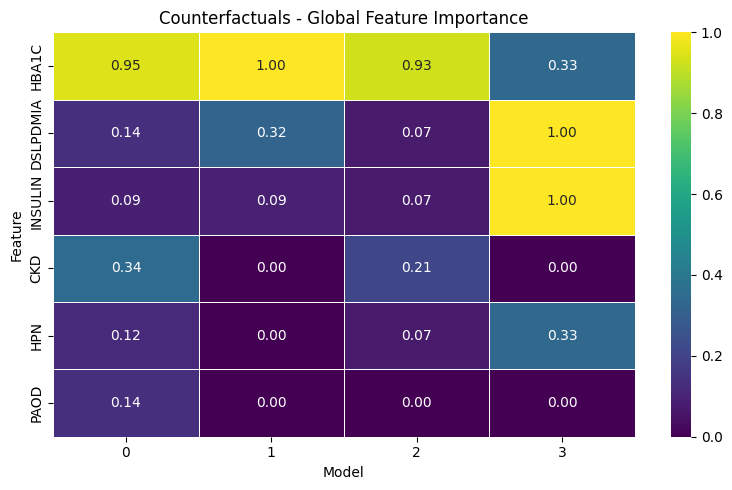

In [51]:
import seaborn as sns
# Build matrix: rows = features, cols = models
imp_df = pd.DataFrame(importance_percent_dict)  # shape: (6 features, 4 models)
imp_df = imp_df.loc[imp_df.mean(axis=1).sort_values(ascending=False).index]
# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(imp_df, annot=True, fmt=".2f", cmap="viridis",
            linewidths=0.5, vmin=0, vmax=1, ax=ax)
ax.set_title("Counterfactuals - Global Feature Importance")
ax.set_xlabel("Model")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(outputdir / 'global_cf.png')

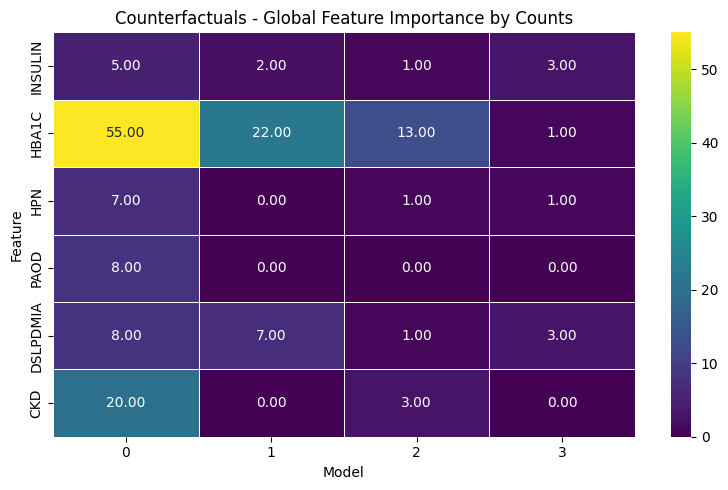

In [52]:
import seaborn as sns
# Build matrix: rows = features, cols = models
imp_df = pd.DataFrame(importance_count_dict)  # shape: (6 features, 4 models)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(imp_df, annot=True, fmt=".2f", cmap="viridis",
            linewidths=0.5, vmin=imp_df.min(axis=None), vmax=imp_df.max(axis=None), ax=ax)
ax.set_title("Counterfactuals - Global Feature Importance by Counts")
ax.set_xlabel("Model")
ax.set_ylabel("Feature")
plt.tight_layout()

## OLD CODE

### Global Importance Summary

In [ ]:
gi_summary_df

### IOI Summary

In [ ]:
ioi_summary_dfs[0]

### Model 0 Summary

In [ ]:
cf_dfs[0] 

### Model 1 Summary

In [ ]:
cf_dfs[1] 

### Model 2 Summary

In [ ]:
cf_dfs[2] 

In [ ]:
cf_dfs_stacked = pd.concat([cf_dfs[i] for i in range(3)], axis=0)
cf_dfs_stacked

### Produce LaTeX Tables

#### Global Importances

In [ ]:
print(gi_summary_df.to_latex(index=False, float_format="{:.3f}".format))

#### Counterfactual Instances Summary

In [ ]:
print(ioi_summary_df.to_latex(index=False, float_format="{:.3f}".format))

#### Models  Summary

In [ ]:
print(cf_dfs_stacked.to_latex(index=False, float_format="{:.3f}".format))

## Plotting of Heatmaps

This assumes that local counterfactuals were already generated

In [ ]:
cf_filename = r"/home/toni_briza/dpn2026/module/experiments/binary/counterfactuals/catboost/final_auprc_f125/split0/nofiltering/019/catboost_split0_local_cf.csv"
cfdf = pd.read_csv(cf_filename)

cfdist_filename = r"/home/toni_briza/dpn2026/module/experiments/binary/counterfactuals/catboost/final_auprc_f125/split0/nofiltering/019/catboost_split0_local_cf_distances.csv"
cfdistdf = pd.read_csv(cfdist_filename)
cfdistdf.head(3)

In [ ]:
unactionable_cols = "SEX,AGE,SUBJ,DM_DUR,GBS".split(',')
cfdistdf[unactionable_cols].iloc[0]

In [ ]:
cfhmap = cfdistdf.drop(['Unnamed: 0.1', 'Unnamed: 0', 'SEX', 'AGE', 'SUBJ', 'DM_DUR', 'Confirmed_Binary_DPN', 'sparsity', 'L1_dist', 'L2_dist'], axis=1)
cfhmap.head(2)

In [ ]:
cfdistdf[unactionable_cols].iloc[0]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your table data
table_data = [
    ["Metric A", "0.85"],
    ["Metric B", "1.22"],
    ["Metric C", "0.45"],
    ["Metric D", "2.10"]
]

patient_data = cfdistdf[unactionable_cols].iloc[0]
patient_table = [[idx, val] for idx, val in patient_data.items()]




# Create figure with 2 columns (heatmap + table)
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[5, 1])  # adjust ratio as needed

# --- Heatmap ---
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    cfhmap.iloc[:15],
    cmap="RdBu",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    cbar_kws={'label': 'Difference'},
    ax=ax1
)

ax1.set_xticklabels(cfhmap.columns, rotation=45, ha='right', fontsize=8)
ax1.set_xlabel("Features")
ax1.set_ylabel("Counterfactuals")

qstr = 19
pred = 1
actual = 0

ax1.set_title(
    f"Counterfactuals for Patient {qstr}: predicted {pred}, actual {actual}",
    fontsize=12,
    pad=20
)

# --- Table ---
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')  # hide axes

table = ax2.table(
    cellText=patient_table,
    # colLabels=["Metric", "Value"],
    loc='center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)  # adjust size

plt.tight_layout()
plt.show()